<a href="https://colab.research.google.com/github/mayatrissnawati-jpg/RegresiLinear_Kelas5B_Kelompok8/blob/main/RegresiLinear_Kelas5B__Kelompok8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


In [2]:
# 2. Memuat Dataset Diamonds & Pembersihan Awal
# Menggunakan dataset bawaan dari seaborn untuk menghindari error FileNotFoundError
df = sns.load_dataset('diamonds')
print(f"Dataset berhasil dimuat dari seaborn. Jumlah baris awal: {len(df)}")

# Membersihkan data duplikat langsung dari awal
df.drop_duplicates(keep='first', inplace=True)
print(f"Dataset berhasil dibersihkan dari duplikat. Jumlah baris sekarang: {len(df)}")

Dataset berhasil dimuat dari seaborn. Jumlah baris awal: 53940
Dataset berhasil dibersihkan dari duplikat. Jumlah baris sekarang: 53794


In [3]:
# 3. Melihat Data Awal
display(df.head())


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
# 4. Informasi Dataset
print(f"Dimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.info()


Dimensi dataset: 53794 baris, 10 kolom
<class 'pandas.core.frame.DataFrame'>
Index: 53794 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53794 non-null  float64 
 1   cut      53794 non-null  category
 2   color    53794 non-null  category
 3   clarity  53794 non-null  category
 4   depth    53794 non-null  float64 
 5   table    53794 non-null  float64 
 6   price    53794 non-null  int64   
 7   x        53794 non-null  float64 
 8   y        53794 non-null  float64 
 9   z        53794 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.4 MB


In [5]:
# 5. Daftar Nama Kolom
print(df.columns.tolist())


['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


In [6]:
# 6. Melihat Data Akhir
display(df.tail())


,carat,cut,color,clarity,depth,table,price,x,y,z
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


## Inspeksi Awal Data (Initial Data Inspection)


### Tujuan Skrip

Notebook ini bertujuan melakukan Exploratory Data Analysis (EDA) pada dataset **Diamonds**.

Tahapan analisis yang dilakukan:

1. Memuat dataset `diamonds.csv`.
2. Melakukan inspeksi awal terhadap jumlah baris, kolom, tipe data, dan isi dataset.
3. Mengecek kualitas data, meliputi missing values dan data duplikat.
4. Menampilkan statistik deskriptif untuk variabel numerik dan kategorikal.
5. Melakukan analisis univariat menggunakan histogram, boxplot, dan countplot.
6. Melakukan analisis bivariat dan multivariat menggunakan korelasi, scatter plot, dan boxplot berdasarkan kategori.
7. Menarik insight berdasarkan hubungan karakteristik berlian dengan harga (`price`).


In [7]:
# Tampilkan 5 baris pertama
print("--- 5 Baris Pertama Data ---")
display(df.head())

# Tampilkan 5 baris terakhir
print("\n--- 5 Baris Terakhir Data ---")
display(df.tail())

# Dimensi data
print(f"\nDimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

# Informasi dataset
print("\n--- Informasi Dataset ---")
df.info()

# Nama kolom
print("\n--- Daftar Nama Kolom ---")
print(df.columns.tolist())


--- 5 Baris Pertama Data ---


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75



--- 5 Baris Terakhir Data ---


,carat,cut,color,clarity,depth,table,price,x,y,z
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64



Dimensi dataset: 53794 baris, 10 kolom

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
Index: 53794 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53794 non-null  float64 
 1   cut      53794 non-null  category
 2   color    53794 non-null  category
 3   clarity  53794 non-null  category
 4   depth    53794 non-null  float64 
 5   table    53794 non-null  float64 
 6   price    53794 non-null  int64   
 7   x        53794 non-null  float64 
 8   y        53794 non-null  float64 
 9   z        53794 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.4 MB

--- Daftar Nama Kolom ---
['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


## Penjelasan Bagian-bagian Penting Skrip

1. **Memuat Dataset**: `pd.read_csv('diamonds.csv')` digunakan untuk membaca dataset Diamonds ke dalam Pandas DataFrame.
2. **Inspeksi Data**: `head()`, `tail()`, `shape`, `info()`, dan `columns` digunakan untuk memahami struktur awal dataset.
3. **Pengecekan Kualitas Data**: dilakukan pemeriksaan terhadap missing values dan data duplikat sebelum analisis lebih lanjut.
4. **Analisis Deskriptif**: digunakan untuk melihat karakteristik umum variabel numerik dan kategorikal.
5. **Visualisasi EDA**: histogram, boxplot, countplot, heatmap, dan scatter plot digunakan untuk melihat distribusi serta hubungan antarvariabel.


## **Pengecekan Kualitas Data Dasar** (Basic Data Quality Checks)


--- Pengecekan Missing Values ---


,Jumlah Missing,Persentase (%)
carat,0,0.0
cut,0,0.0
color,0,0.0
clarity,0,0.0
depth,0,0.0
table,0,0.0
price,0,0.0
x,0,0.0
y,0,0.0
z,0,0.0


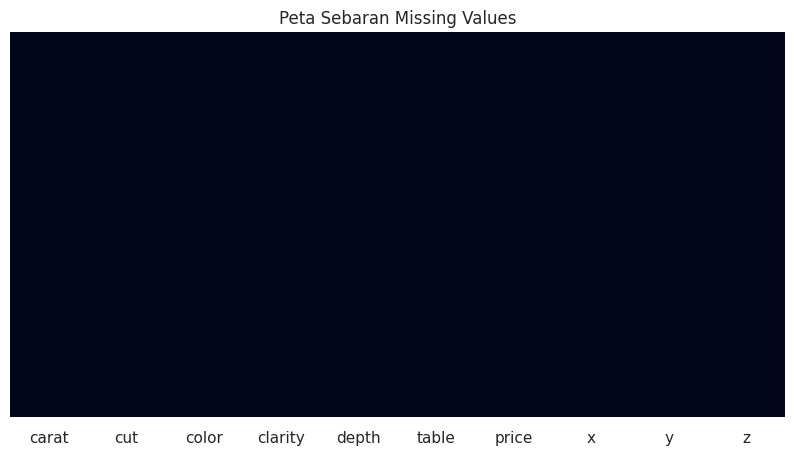


--- Pengecekan Data Duplikat ---
Jumlah baris duplikat identik: 0


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Pengecekan Missing Values ---")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_table = pd.concat(
    [missing_data, missing_percent],
    axis=1,
    keys=['Jumlah Missing', 'Persentase (%)']
)

display(missing_table)

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False)
plt.title('Peta Sebaran Missing Values')
plt.show()

print("\n--- Pengecekan Data Duplikat ---")
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat identik: {jumlah_duplikat}")

if jumlah_duplikat > 0:
    print("\nContoh data duplikat:")
    display(df[df.duplicated(keep=False)].head(10))


### Ringkasan Pengecekan Kualitas Data

Hasil pengecekan pada dataset **Diamonds** menunjukkan:

- Dataset awalnya memiliki **53.940 baris**.
- Tidak ditemukan **missing values** pada seluruh kolom.
- Ditemukan **146 baris duplikat identik**, yang **telah langsung dibersihkan** pada tahap awal dengan menyisakan baris pertama saja, sehingga dataset bersih kini berjumlah **53.794 baris**.
- Terdapat satu kolom `Unnamed: 0` yang berfungsi seperti nomor indeks pada file CSV, namun karena kita memuat dataset langsung dari seaborn, kolom indeks tambahan ini tidak ada.

Dengan pembersihan ini, analisis univariat, bivariat, serta pemodelan regresi setelahnya berjalan menggunakan data yang sepenuhnya bersih dan valid.

## **Statistik Deskriptif (Descriptive Statistics)**


In [9]:
# Kolom indeks tidak digunakan dalam analisis
df_eda = df.drop(columns=['Unnamed: 0'], errors='ignore')

print("--- Statistik Deskriptif untuk Kolom Numerik ---")
display(df_eda.describe())

print("\n--- Statistik Deskriptif untuk Kolom Kategorikal ---")
# Menggunakan include='category' karena kolom kategori di dataset ini bertipe category, bukan object
display(df_eda.describe(include='category'))

--- Statistik Deskriptif untuk Kolom Numerik ---


,carat,depth,table,price,x,y,z
count,53794.00000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.79778,61.748080,57.458109,3933.065082,5.731214,5.734653,3.538714
std,0.47339,1.429909,2.233679,3988.114460,1.120695,1.141209,0.705037
min,0.20000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.40000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.70000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.04000,62.500000,59.000000,5326.750000,6.540000,6.540000,4.030000
max,5.01000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000



--- Statistik Deskriptif untuk Kolom Kategorikal ---


,cut,color,clarity
count,53794,53794,53794
unique,5,7,8
top,Ideal,G,SI1
freq,21488,11262,13032


### Ringkasan Statistik Deskriptif

Dataset Diamonds memiliki beberapa variabel numerik seperti `carat`, `depth`, `table`, `price`, `x`, `y`, dan `z`, serta variabel kategorikal `cut`, `color`, dan `clarity`.

Beberapa hal yang terlihat dari statistik deskriptif:

- `carat` memiliki nilai rata-rata sekitar **0,80** dan maksimum **5,01**.
- `price` memiliki rata-rata sekitar **3.933** dengan nilai maksimum **18.823**.
- `cut` memiliki 5 kategori, dengan kategori **Ideal** sebagai kategori yang paling banyak muncul.
- `color` memiliki 7 kategori, dengan **G** sebagai kategori yang paling banyak muncul.
- `clarity` memiliki 8 kategori, dengan **SI1** sebagai kategori yang paling banyak muncul.

Nilai minimum dan maksimum pada beberapa variabel juga menunjukkan adanya rentang data yang cukup lebar, sehingga boxplot diperlukan untuk melihat kemungkinan outlier.


## **Analisis Univariat (Univariate Analysis)**


### Analisis Univariat untuk Kolom Numerik ###


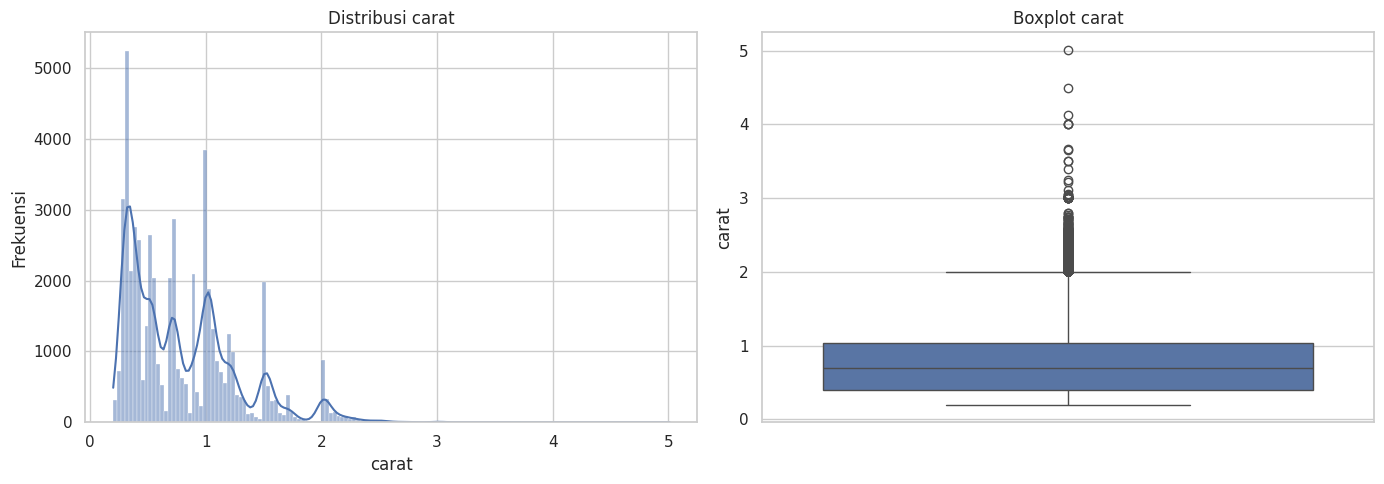

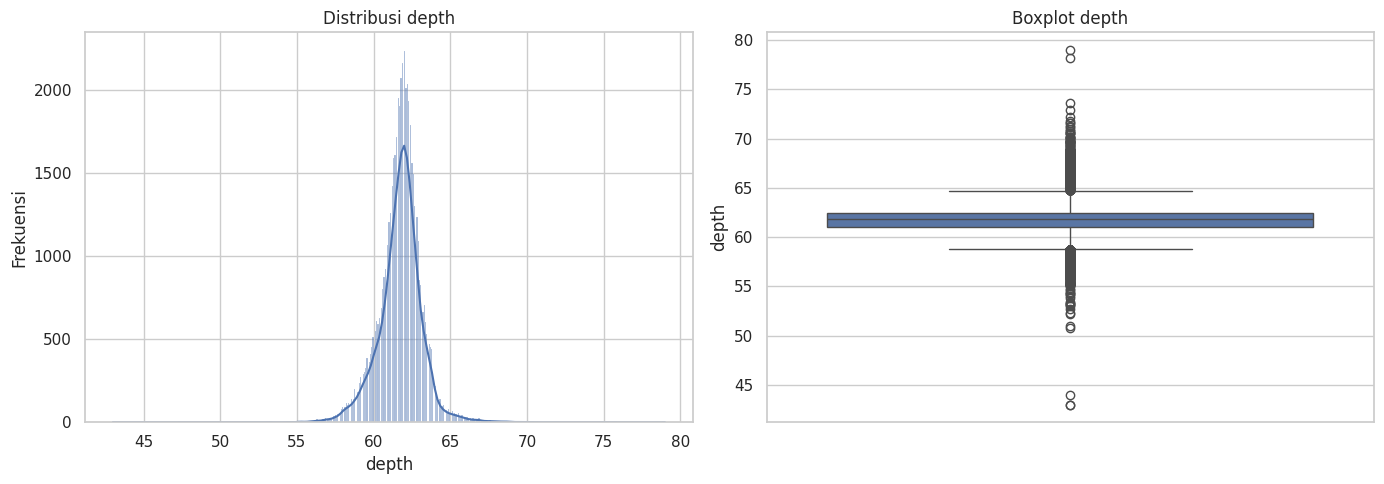

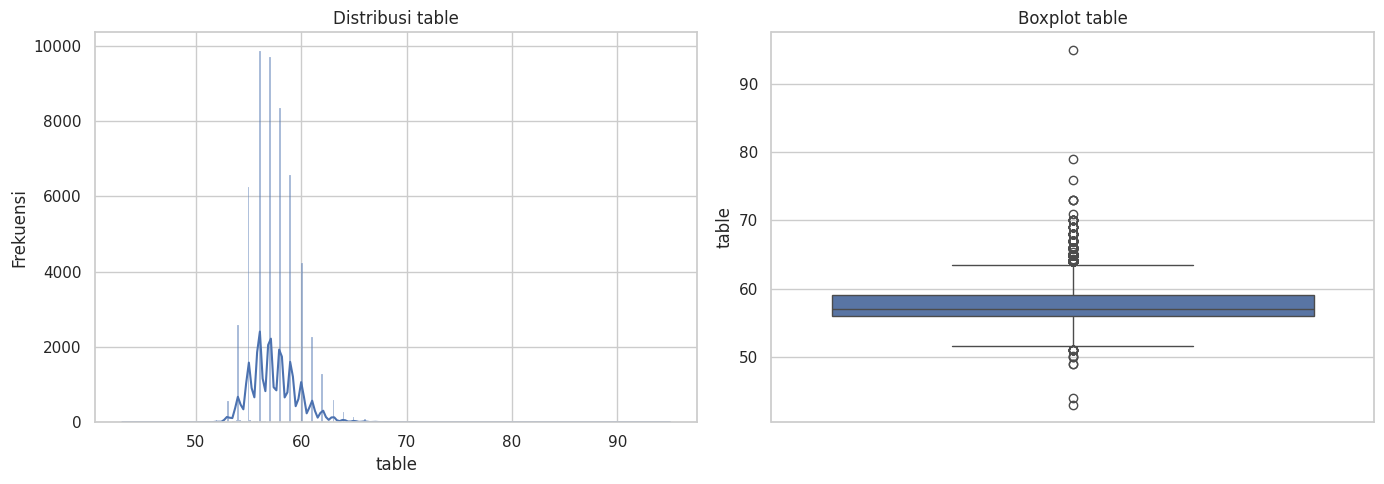

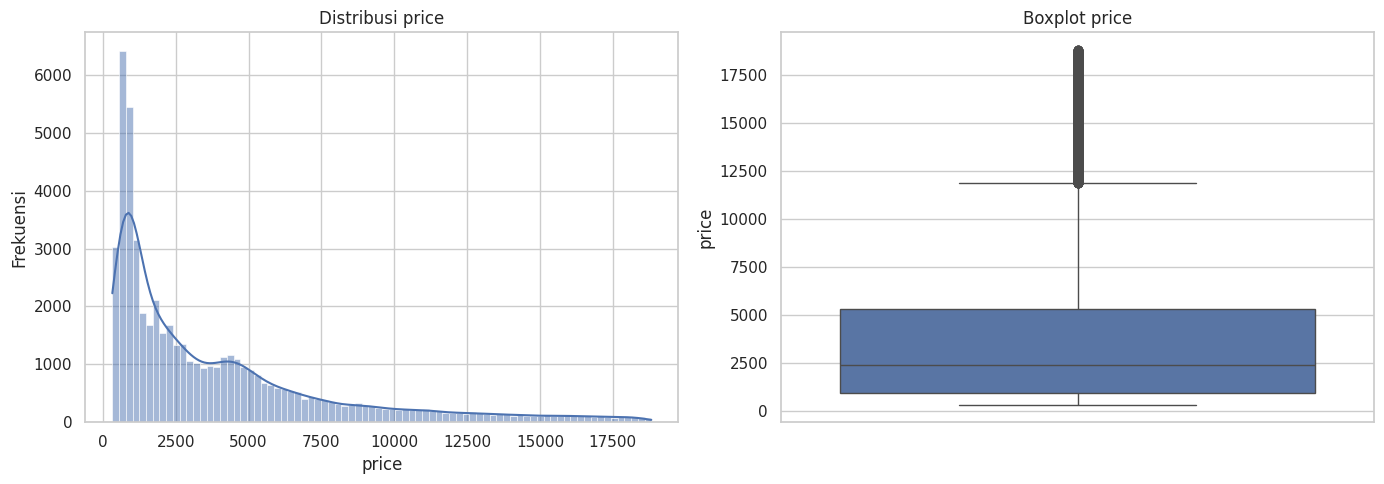

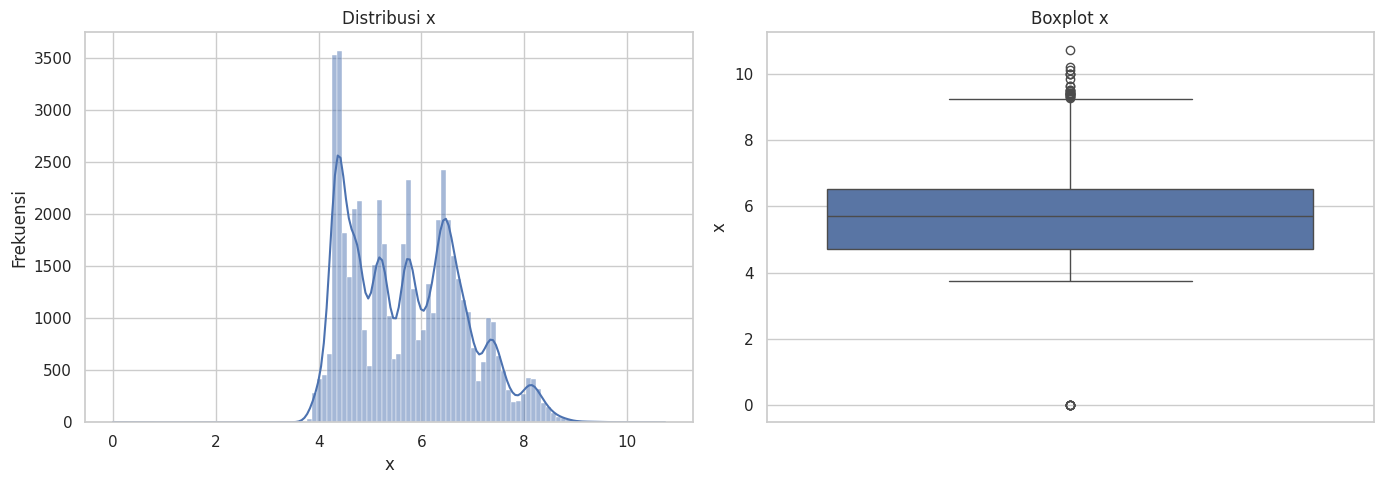

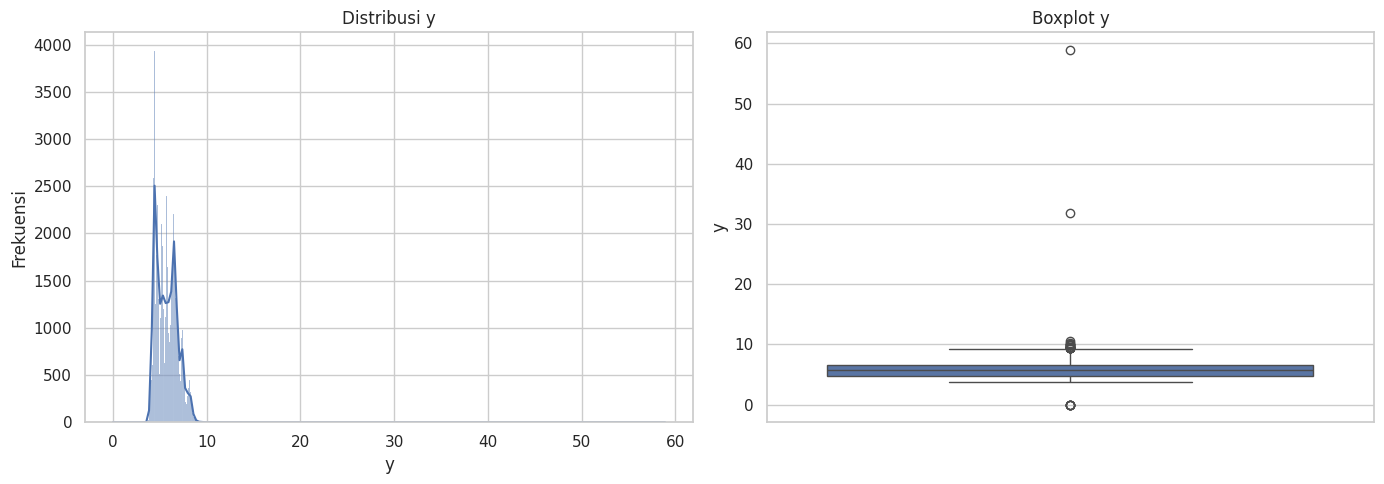

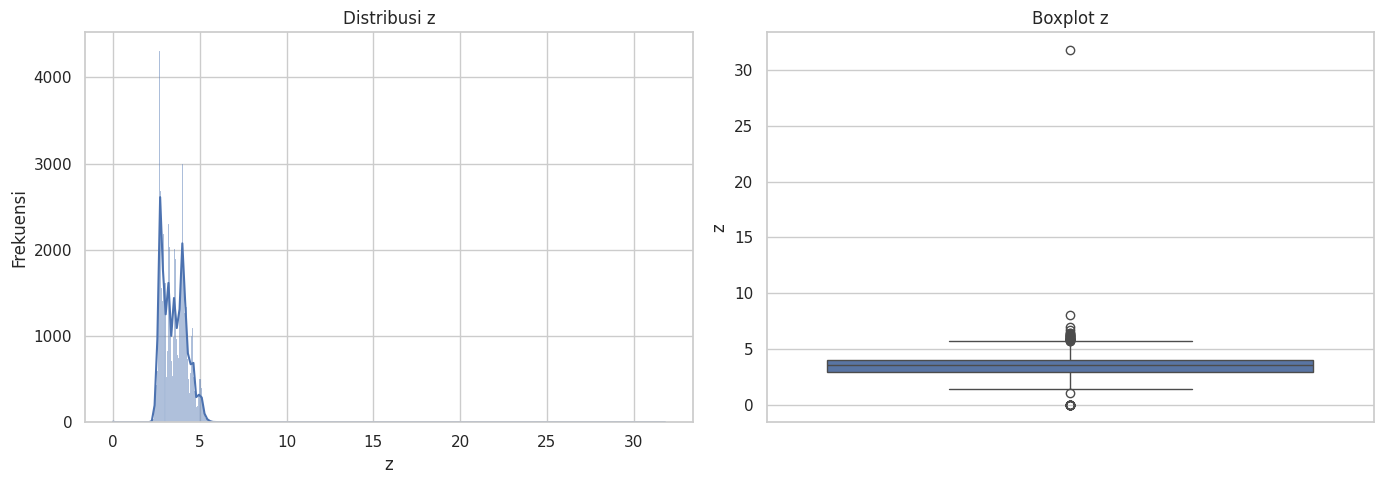


### Analisis Univariat untuk Kolom Kategorikal ###


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memisahkan kolom numerik dan kategorikal
df_eda = df.drop(columns=['Unnamed: 0'], errors='ignore')
kolom_numerik = df_eda.select_dtypes(include=['int64', 'float64']).columns.tolist()
kolom_kategorikal = df_eda.select_dtypes(include=['object']).columns.tolist()

print("### Analisis Univariat untuk Kolom Numerik ###")

for kolom in kolom_numerik:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df_eda[kolom], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribusi {kolom}')
    axes[0].set_xlabel(kolom)
    axes[0].set_ylabel('Frekuensi')

    sns.boxplot(y=df_eda[kolom], ax=axes[1])
    axes[1].set_title(f'Boxplot {kolom}')
    axes[1].set_ylabel(kolom)

    plt.tight_layout()
    plt.show()

print("\n### Analisis Univariat untuk Kolom Kategorikal ###")

for kolom in kolom_kategorikal:
    plt.figure(figsize=(9, 5))
    sns.countplot(
        data=df_eda,
        y=kolom,
        order=df_eda[kolom].value_counts().index
    )
    plt.title(f'Distribusi {kolom}')
    plt.xlabel('Jumlah')
    plt.ylabel(kolom)
    plt.tight_layout()
    plt.show()


### Ringkasan Hasil Analisis Univariat

Dari analisis univariat pada dataset Diamonds:

- `carat` menunjukkan distribusi yang cenderung miring ke kanan, sehingga sebagian besar berlian memiliki ukuran karat relatif kecil dan hanya sebagian yang memiliki karat besar.
- `price` juga memiliki distribusi yang miring ke kanan, dengan sebagian besar harga berada pada rentang rendah hingga menengah dan beberapa berlian memiliki harga sangat tinggi.
- Variabel ukuran `x`, `y`, dan `z` memiliki pola yang berkaitan dengan ukuran fisik berlian dan juga menunjukkan beberapa nilai ekstrem.
- Untuk kategori, `cut`, `color`, dan `clarity` memiliki jumlah observasi yang tidak sama pada setiap kategorinya.
- Boxplot membantu menunjukkan adanya nilai ekstrem yang perlu diperhatikan, terutama pada variabel ukuran dan harga.


## **Analisis Bivariat & Multivariat (Bivariate & Multivariate Analysis)**


### 1. Heatmap Korelasi Antar Kolom Numerik ###


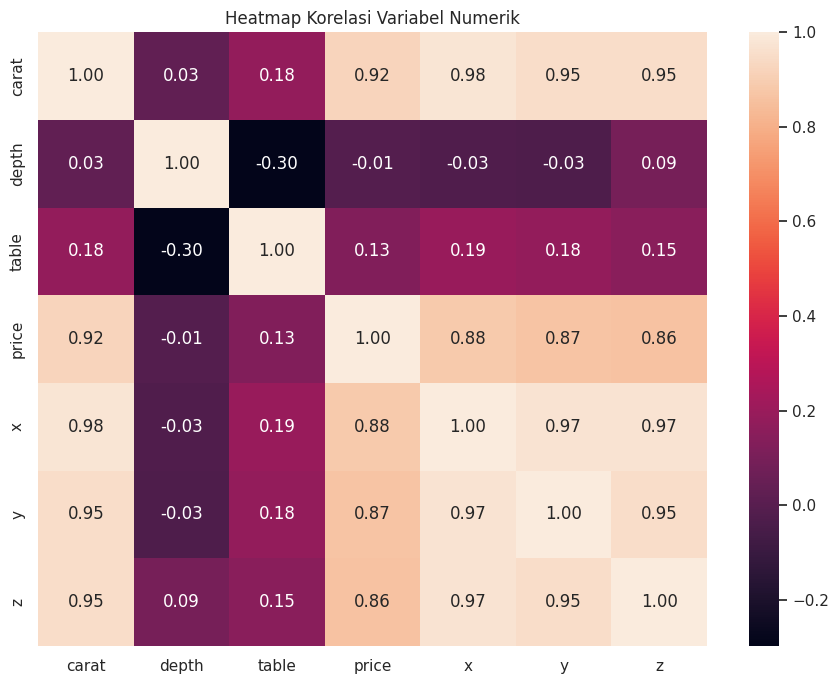


### 2. Hubungan Carat dan Price ###


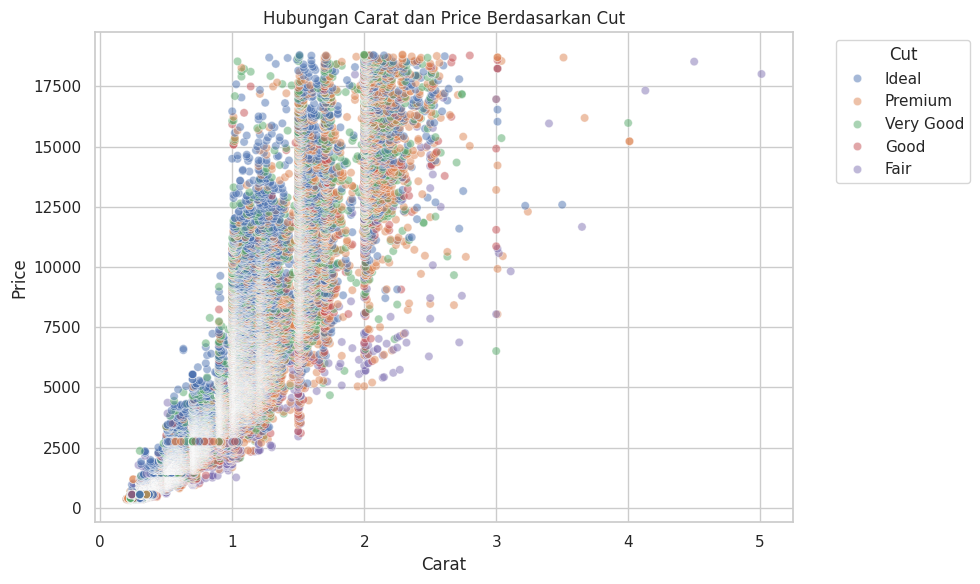


### 3. Perbandingan Price Berdasarkan Cut ###


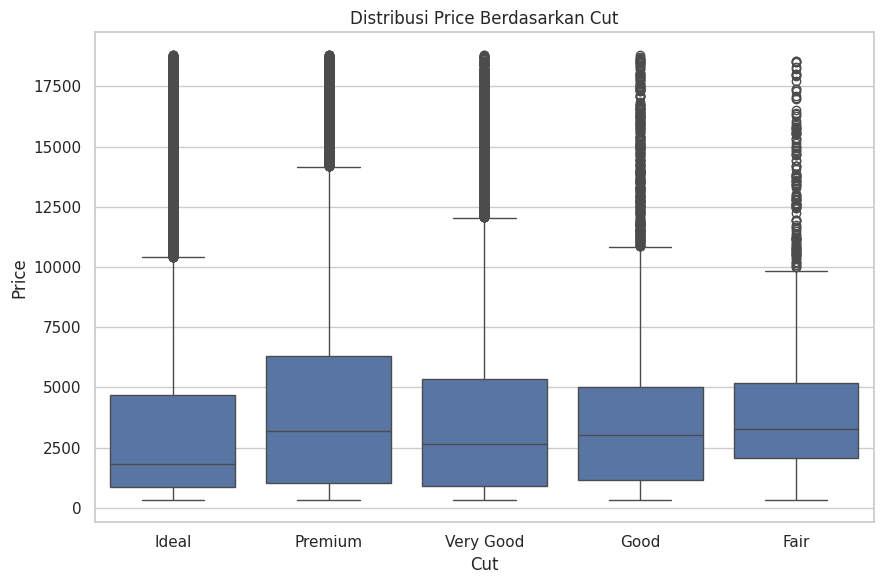


### 4. Perbandingan Price Berdasarkan Color ###


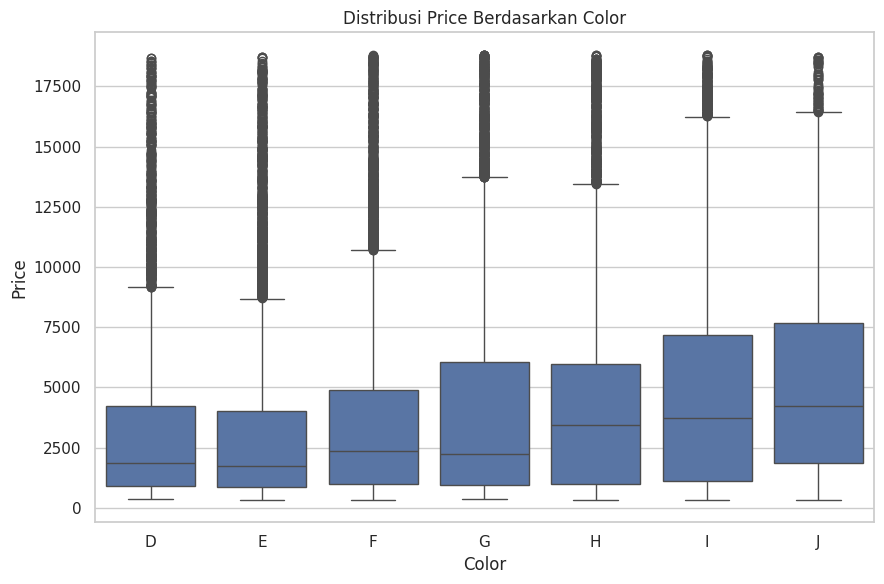


### 5. Perbandingan Price Berdasarkan Clarity ###


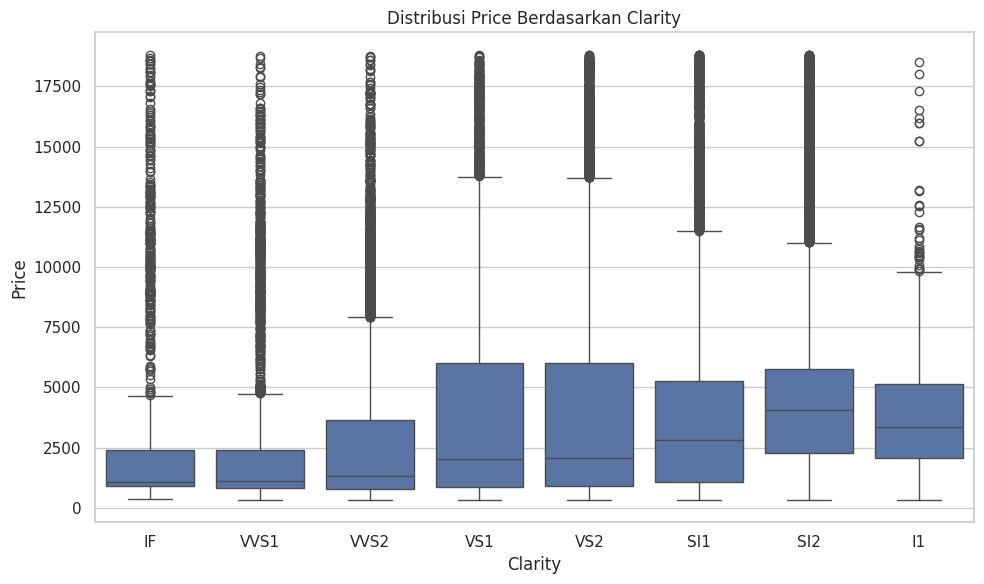

In [11]:
df_eda = df.drop(columns=['Unnamed: 0'], errors='ignore')

print("### 1. Heatmap Korelasi Antar Kolom Numerik ###")
plt.figure(figsize=(9, 7))
correlation_matrix = df_eda.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title('Heatmap Korelasi Variabel Numerik')
plt.tight_layout()
plt.show()

print("\n### 2. Hubungan Carat dan Price ###")
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_eda,
    x='carat',
    y='price',
    hue='cut',
    alpha=0.5
)
plt.title('Hubungan Carat dan Price Berdasarkan Cut')
plt.xlabel('Carat')
plt.ylabel('Price')
plt.legend(title='Cut', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n### 3. Perbandingan Price Berdasarkan Cut ###")
plt.figure(figsize=(9, 6))
sns.boxplot(data=df_eda, x='cut', y='price')
plt.title('Distribusi Price Berdasarkan Cut')
plt.xlabel('Cut')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

print("\n### 4. Perbandingan Price Berdasarkan Color ###")
plt.figure(figsize=(9, 6))
sns.boxplot(data=df_eda, x='color', y='price')
plt.title('Distribusi Price Berdasarkan Color')
plt.xlabel('Color')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

print("\n### 5. Perbandingan Price Berdasarkan Clarity ###")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_eda, x='clarity', y='price')
plt.title('Distribusi Price Berdasarkan Clarity')
plt.xlabel('Clarity')
plt.ylabel('Price')
plt.tight_layout()
plt.show()


### Ringkasan Hasil Analisis Bivariat & Multivariat

Beberapa hubungan penting yang terlihat dari dataset Diamonds:

1. **Carat dan Price** memiliki hubungan positif yang sangat kuat. Korelasi `carat` terhadap `price` sekitar **0,92**, sehingga berlian dengan karat lebih besar cenderung memiliki harga lebih tinggi.
2. Variabel ukuran fisik `x`, `y`, dan `z` juga memiliki korelasi positif yang kuat terhadap `price`.
3. `depth` memiliki hubungan yang sangat lemah terhadap `price`, sedangkan `table` memiliki hubungan positif tetapi relatif lemah.
4. Boxplot berdasarkan `cut`, `color`, dan `clarity` menunjukkan bahwa distribusi harga berbeda antar kategori.
5. Perbedaan rata-rata harga antar kategori tidak selalu berarti kategori dengan kualitas yang secara konsep lebih tinggi akan selalu memiliki harga paling tinggi, karena harga juga dipengaruhi oleh ukuran (`carat`) dan karakteristik lainnya.


## **Catatan Kesimpulan dan Langkah Selanjutnya (Insights & Next Steps)**


### Ringkasan Temuan Utama dari Eksplorasi Data (EDA)

Berdasarkan EDA pada dataset **Diamonds**, dapat disimpulkan:

1. **Dataset lengkap tetapi memiliki duplikasi:** tidak terdapat missing values, namun ditemukan **146 baris duplikat**.
2. **Carat merupakan variabel yang sangat berkaitan dengan harga:** korelasi `carat` dan `price` sekitar **0,92**, sehingga ukuran karat menjadi salah satu variabel penting untuk menjelaskan harga berlian.
3. **Ukuran fisik juga berkaitan dengan harga:** variabel `x`, `y`, dan `z` memiliki korelasi positif yang cukup kuat terhadap `price`.
4. **Harga memiliki sebaran yang lebar:** `price` memiliki nilai dari **326** hingga **18.823**, sehingga distribusinya cenderung miring ke kanan.
5. **Kategori cut, color, dan clarity menunjukkan perbedaan distribusi harga:** namun hubungan tersebut sebaiknya dianalisis bersama variabel lain karena harga berlian tidak ditentukan oleh satu karakteristik saja.

### Langkah Selanjutnya

EDA ini dapat dilanjutkan dengan:
- membersihkan atau menangani data duplikat;
- melakukan analisis outlier dengan metode IQR;
- melakukan encoding pada variabel kategorikal;
- membuat model regresi untuk memprediksi `price`;
- mengevaluasi variabel mana yang paling berpengaruh terhadap harga berlian.


In [12]:
# Preprocessing #

# Menggunakan errors='ignore' agar tidak terjadi error jika kolom tidak ditemukan
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Membersihkan data duplikat (menyimpan data pertama yang muncul, menghapus salinan berikutnya)
print(f"Jumlah baris sebelum dibersihkan: {len(df)}")
df.drop_duplicates(keep='first', inplace=True)
print(f"Jumlah baris setelah dibersihkan dari duplikat: {len(df)}")

display(df.head())

Jumlah baris sebelum dibersihkan: 53794
Jumlah baris setelah dibersihkan dari duplikat: 53794


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [13]:
# 2. Mengecek missing value

print("Jumlah missing value setiap kolom:")
print(df.isnull().sum())

print("\nTotal missing value:")
print(df.isnull().sum().sum())

Jumlah missing value setiap kolom:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Total missing value:
0


In [14]:
# 3. Memisahkan fitur (X) dan target (y)

X = df.drop(columns=['price'])
y = df['price']

print("Fitur (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

Fitur (X):


,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75



Target (y):


,price
0,326
1,326
2,327
3,334
4,335


In [15]:
# 4. Ordinal Encoding pada variabel cut

X['cut'] = X['cut'].map({
    'Fair': 0,
    'Good': 1,
    'Very Good': 2,
    'Premium': 3,
    'Ideal': 4
}).astype(int)

display(X[['cut']].head(10))

,cut
0,4
1,3
2,1
3,3
4,1
5,2
6,2
7,2
8,0
9,2


In [16]:
# 6. Ordinal Encoding pada variabel clarity

X['clarity'] = X['clarity'].map({
    'I1': 0,
    'SI2': 1,
    'SI1': 2,
    'VS2': 3,
    'VS1': 4,
    'VVS2': 5,
    'VVS1': 6,
    'IF': 7
}).astype(int)

display(X[['clarity']].head(10))

,clarity
0,1
1,2
2,4
3,3
4,1
5,5
6,6
7,2
8,3
9,4


In [17]:
# 6.5. Ordinal Encoding pada variabel color
# Urutan warna berlian dari terbaik (D) ke terendah (J)
X['color'] = X['color'].map({
    'J': 0,
    'I': 1,
    'H': 2,
    'G': 3,
    'F': 4,
    'E': 5,
    'D': 6
}).astype(int)

display(X[['color']].head(10))

,color
0,5
1,5
2,5
3,1
4,0
5,0
6,1
7,2
8,5
9,2


In [18]:
# 7. Mengecek hasil ordinal encoding

display(X.head())

print("Tipe data setiap kolom:")
print(X.dtypes)

,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,4,5,1,61.5,55.0,3.95,3.98,2.43
1,0.21,3,5,2,59.8,61.0,3.89,3.84,2.31
2,0.23,1,5,4,56.9,65.0,4.05,4.07,2.31
3,0.29,3,1,3,62.4,58.0,4.20,4.23,2.63
4,0.31,1,0,1,63.3,58.0,4.34,4.35,2.75


Tipe data setiap kolom:
carat      float64
cut          int64
color        int64
clarity      int64
depth      float64
table      float64
x          float64
y          float64
z          float64
dtype: object


In [19]:
# 8. Membagi data menjadi training dan testing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

Ukuran X_train: (37655, 9)
Ukuran X_test : (16139, 9)
Ukuran y_train: (37655,)
Ukuran y_test : (16139,)


In [20]:
# 9. Standardisasi fitur

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# 10. Mengubah hasil scaling menjadi DataFrame

X_train = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

display(X_train.head())

,carat,cut,color,clarity,depth,table,x,y,z
45307,-1.048977,0.984987,1.523367,-0.637953,-0.036723,-0.204891,-1.291914,-1.268254,-1.277513
15892,0.439933,0.984987,-0.236053,-0.028904,-0.106657,-0.652562,0.643521,0.614842,0.615184
22182,0.439933,0.088495,1.523367,1.189194,0.452816,1.138123,0.510349,0.552664,0.586507
48310,-1.153830,0.984987,0.350420,-0.028904,-0.106657,-1.100234,-1.487233,-1.472552,-1.478254
32731,-1.028007,0.088495,0.350420,-0.028904,0.382882,0.690452,-1.238645,-1.286019,-1.220159


In [22]:
# 11. Verifikasi hasil preprocessing

print("Missing value X_train:", X_train.isnull().sum().sum())
print("Missing value X_test :", X_test.isnull().sum().sum())

print("\nTipe data X_train:")
print(X_train.dtypes)

Missing value X_train: 0
Missing value X_test : 0

Tipe data X_train:
carat      float64
cut        float64
color      float64
clarity    float64
depth      float64
table      float64
x          float64
y          float64
z          float64
dtype: object


In [23]:
# 12. Statistik data setelah standardisasi

display(X_train.describe())

,carat,cut,color,clarity,depth,table,x,y,z
count,3.765500e+04,3.765500e+04,3.765500e+04,3.765500e+04,3.765500e+04,3.765500e+04,3.765500e+04,3.765500e+04,3.765500e+04
mean,-1.932269e-16,1.853015e-16,-2.547424e-17,-2.698383e-17,2.578796e-15,-8.057409e-16,6.491215e-17,-4.966534e-16,3.713579e-16
std,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00
min,-1.258683e+00,-2.600984e+00,-1.995474e+00,-1.856051e+00,-1.311441e+01,-6.472290e+00,-5.091758e+00,-5.096624e+00,-5.077247e+00
25%,-8.392717e-01,-8.079983e-01,-8.225269e-01,-6.379527e-01,-5.262624e-01,-6.525623e-01,-9.101539e-01,-9.040704e-01,-9.047092e-01
50%,-2.101546e-01,8.849460e-02,-2.360534e-01,-2.890375e-02,3.321107e-02,-2.048909e-01,-3.121791e-02,-2.470006e-02,-1.571479e-02
75%,5.238154e-01,9.849875e-01,9.368935e-01,5.801452e-01,5.227503e-01,6.904517e-01,7.234241e-01,7.125498e-01,7.155548e-01
max,8.828161e+00,9.849875e-01,1.523367e+00,2.407292e+00,1.206189e+01,1.680662e+01,4.443365e+00,2.314982e+01,4.931109e+00


In [24]:
# 13. Menyiapkan data untuk regresi linear

# Menggunakan data hasil encoding sebelum scaling
X_reg = X.copy()
y_reg = y.copy()

print("Ukuran fitur:", X_reg.shape)
print("Ukuran target:", y_reg.shape)

Ukuran fitur: (53794, 9)
Ukuran target: (53794,)


In [25]:
# 14. Membagi data menjadi training dan testing

from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Data training:", X_train_reg.shape)
print("Data testing :", X_test_reg.shape)

Data training: (43035, 9)
Data testing : (10759, 9)


In [26]:
# 15. Membuat dan melatih model regresi linear

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_reg, y_train_reg)

print("Model regresi linear berhasil dilatih.")

Model regresi linear berhasil dilatih.


In [27]:
# 16. Melihat intercept dan koefisien model

print("Intercept:", model.intercept_)

print("\nKoefisien setiap fitur:")

for nama, koef in zip(X_train_reg.columns, model.coef_):
    print(nama, "=", round(koef, 3))

Intercept: 4008.524950797273

Koefisien setiap fitur:
carat = 10749.634
cut = 120.64
color = 321.63
clarity = 503.22
depth = -84.322
table = -26.522
x = -893.908
y = 24.895
z = 22.484


In [28]:
# 17. Membuat prediksi pada data testing

y_pred = model.predict(X_test_reg)

print("5 hasil prediksi pertama:")
print(y_pred[:5])

5 hasil prediksi pertama:
[1432.08568597 4077.1855371  2343.67887942 1766.51909551 6085.77446099]


In [29]:
# 18. Evaluasi model menggunakan MSE, RMSE, dan R²

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred)

print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 3))

MSE  : 1402687.8
RMSE : 1184.35
R²   : 0.908


In [30]:
# 19. Menghitung residual

residual = y_test_reg - y_pred

print("5 residual pertama:")
print(residual.head())

5 residual pertama:
43657      2.914314
4274    -493.185537
47412   -492.678879
44437   -176.519096
13975   -395.774461
Name: price, dtype: float64


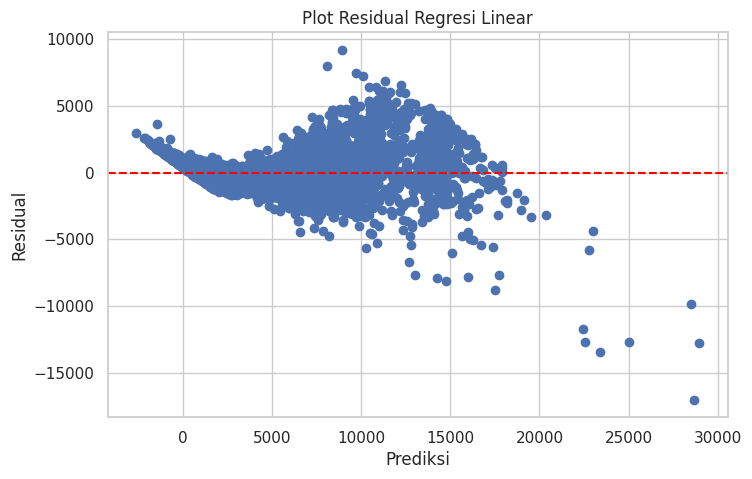

In [31]:
# 20. Visualisasi residual

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residual)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel('Prediksi')
plt.ylabel('Residual')
plt.title('Plot Residual Regresi Linear')

plt.show()

In [32]:
# 21. Ringkasan hasil regresi

print("===== HASIL REGRESI LINEAR =====")
print("Jumlah data training :", len(X_train_reg))
print("Jumlah data testing  :", len(X_test_reg))
print("Intercept             :", round(model.intercept_, 3))

print("\nKoefisien:")
for nama, koef in zip(X_train_reg.columns, model.coef_):
    print(f"{nama:10} : {koef:.3f}")

print("\nEvaluasi Model:")
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 3))

===== HASIL REGRESI LINEAR =====
Jumlah data training : 43035
Jumlah data testing  : 10759
Intercept             : 4008.525

Koefisien:
carat      : 10749.634
cut        : 120.640
color      : 321.630
clarity    : 503.220
depth      : -84.322
table      : -26.522
x          : -893.908
y          : 24.895
z          : 22.484

Evaluasi Model:
MSE  : 1402687.8
RMSE : 1184.35
R²   : 0.908
